# MLP Regression on California Housing (Beginner Tutorial)

This notebook is a complete regression tutorial, from data checks to residual diagnostics. The intent is to teach both modeling and interpretation.

Learning goals: by the end, you should be able to build a leakage-safe regression pipeline, compare baseline vs MLP outcomes, and interpret MAE/RMSE/R2 together with residual plots.

Use the same workflow in every section: read the concept first, predict what you expect, run the code, and then explain what the output means in plain language.


## 1. Imports + Reproducibility Seed

This section initializes required libraries and fixes randomness for controlled experiments.

How to read this step: output is usually minimal, so success means imports complete and seeds are set before any stochastic training step.

Contextual interpretation: without seed control, small architecture changes can look like major improvements purely due to randomness.

Go deeper: [TensorFlow/Keras built-in training methods](https://www.tensorflow.org/guide/keras/training_with_built_in_methods).


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.manifold import TSNE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load Dataset

Now you load California Housing and verify predictor/target schema.

How to read the output: use shape for scale and preview for semantics. Make sure target meaning is explicit now, because MAE/RMSE/R2 interpretation depends on target definition.

If schema is unclear at this stage, downstream metric interpretation will be unreliable.

Go deeper: [fetch_california_housing](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html).


In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.rename(columns={'MedHouseVal': 'target'}).copy()

feature_cols = [c for c in df.columns if c != 'target']

print('Shape:', df.shape)
df.head()


Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Data Quality Check

You inspect missing values and duplicates before EDA or training.

How to read the output: review missing counts by column, duplicate counts, and final shape after cleanup. Large changes should be recorded, because they can influence both model training and metric behavior.

Interpretation rule: quality operations alter training data distribution, so this section is part of modeling logic, not just preprocessing formality.

Go deeper: [Common pitfalls in scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html).


In [3]:
print('Missing values by column:\n', df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())

df = df.drop_duplicates().copy()
print('Shape after duplicate removal:', df.shape)


Missing values by column:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64
Duplicate rows: 0
Shape after duplicate removal: (20640, 9)


## 4. EDA (PCA + t-SNE)

This section builds structural intuition using direct plots plus PCA/t-SNE.

How to read the PCA printout: named values (`PC1`, `PC2`) show variance share captured by each component, and cumulative variance shows how much of total feature variation is retained in 2D. Example: `PC1=0.54`, `PC2=0.21` means ~75% retained.

How to read PCA composition output: the loadings table shows which original features shape PC1 and PC2 most strongly. Larger absolute loading means stronger influence; loading sign indicates direction on that axis, not feature quality.

How to interpret that in regression context: high retained variance in PCA helps you trust the projection as a broad structural summary, but it does not guarantee strong target predictability. t-SNE can reveal local neighborhoods and potential substructure, but remains exploratory.

Use these views to form hypotheses about where residual patterns may appear after training.

Go deeper on dimensionality reduction and interpretation: [scikit-learn PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca), [scikit-learn t-SNE](https://scikit-learn.org/stable/modules/manifold.html#t-sne), [How to Use t-SNE Effectively (Distill)](https://distill.pub/2016/misread-tsne/), and [van der Maaten & Hinton (2008)](https://www.jmlr.org/papers/v9/vandermaaten08a.html).


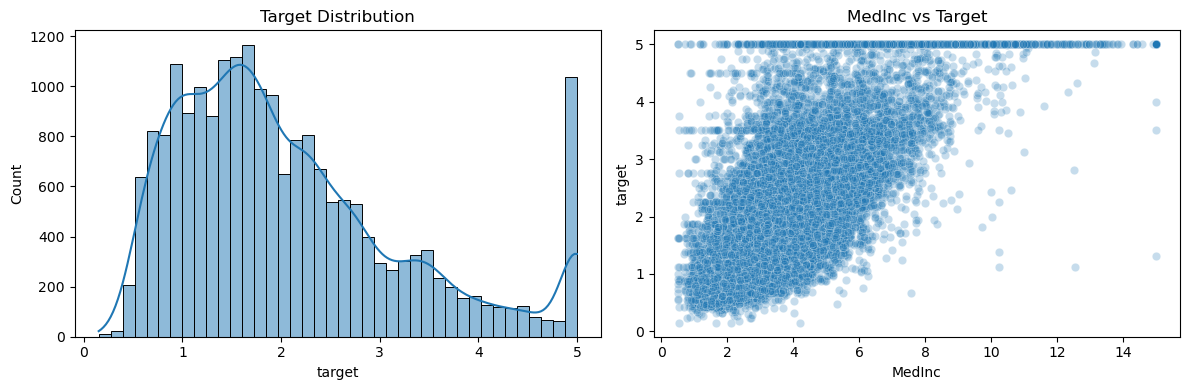

PCA explained variance ratio -> PC1: 0.2534, PC2: 0.2352
PCA cumulative explained variance (PC1+PC2): 0.4885

PCA component loadings (feature contributions):


,PC1_loading,PC2_loading
MedInc,0.0775,0.2299
HouseAge,0.0073,-0.2608
AveRooms,0.4391,0.5467
AveBedrms,0.4000,0.5018
Population,-0.1718,0.1006
AveOccup,-0.0146,0.0026
Latitude,0.5684,-0.3740
Longitude,-0.5370,0.4224


Top features shaping PC1: Latitude, Longitude, AveRooms
Top features shaping PC2: AveRooms, AveBedrms, Longitude


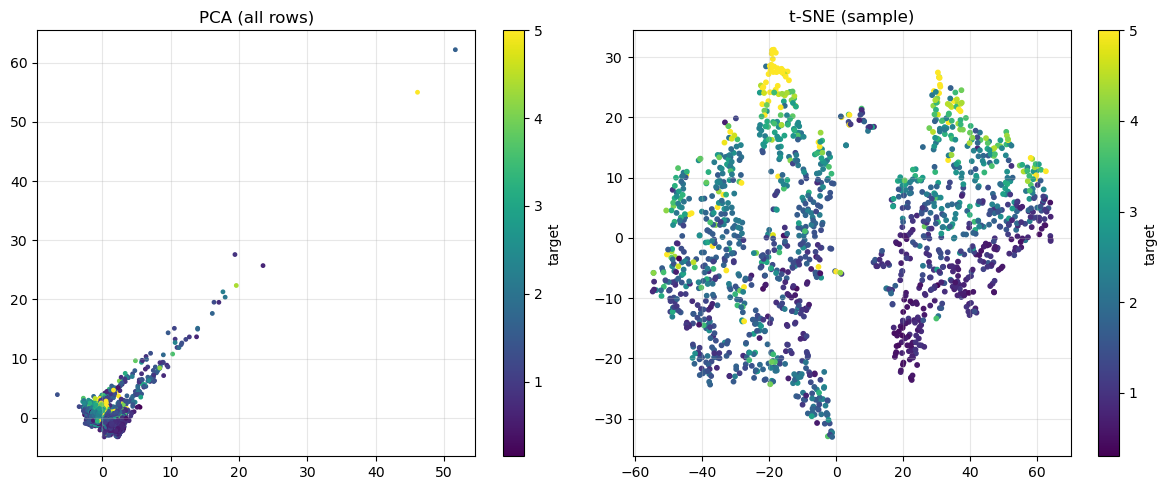

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['target'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Target Distribution')

sns.scatterplot(x=df['MedInc'], y=df['target'], alpha=0.25, ax=axes[1])
axes[1].set_title('MedInc vs Target')
plt.tight_layout()
plt.show()

X_eda = df[feature_cols].to_numpy()
y_eda = df['target'].to_numpy()

X_eda_scaled = StandardScaler().fit_transform(X_eda)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_eda_scaled)
explained = pca.explained_variance_ratio_
print(f"PCA explained variance ratio -> PC1: {explained[0]:.4f}, PC2: {explained[1]:.4f}")
print(f"PCA cumulative explained variance (PC1+PC2): {explained.sum():.4f}")

# PCA composition: feature loadings for each component.
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1_loading', 'PC2_loading'],
)
print()
print("PCA component loadings (feature contributions):")
display(loadings.style.format('{:.4f}'))

for pc in ['PC1_loading', 'PC2_loading']:
    top_features = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    print(f"Top features shaping {pc.replace('_loading', '')}: {', '.join(top_features)}")

# Runtime-safe t-SNE on a sample.
sample_n = min(1500, len(X_eda_scaled))
idx = np.random.choice(len(X_eda_scaled), size=sample_n, replace=False)
X_tsne = TSNE(n_components=2, perplexity=30, max_iter=900, random_state=SEED).fit_transform(X_eda_scaled[idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_eda, cmap='viridis', s=6)
axes[0].set_title('PCA (all rows)')
axes[0].grid(alpha=0.3)
plt.colorbar(sc0, ax=axes[0], label='target')

sc1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_eda[idx], cmap='viridis', s=10)
axes[1].set_title('t-SNE (sample)')
axes[1].grid(alpha=0.3)
plt.colorbar(sc1, ax=axes[1], label='target')

plt.tight_layout()
plt.show()


## 5. Preprocessing

This section explicitly constructs `X` and `y` and applies robust preparation.

How to read the output: confirm `X` sample count matches `y` sample count and that predictor matrix dimensions look reasonable for downstream scaling.

If counts diverge, correct preprocessing first; model metrics are meaningless until alignment is fixed.


In [5]:
X = df[feature_cols].copy()
y = df['target'].to_numpy()

# Median fill keeps this beginner example robust even if missing data appears.
X = X.fillna(X.median(numeric_only=True))

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (20640, 8)
y shape: (20640,)


## 6. Train/Val/Test Split

This section performs splitting and leakage-safe scaling.

How to read the output: verify train/val/test shape integrity, constant feature dimensions across splits, and sample-total consistency with cleaned dataset size.

Contextual interpretation: leakage or shape mismatch here invalidates all later MAE/RMSE/R2 comparisons.

Go deeper on leakage-safe splitting and scaling: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [data leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage), and [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
)

scaler = StandardScaler()
# Fit only on training features to avoid data leakage.
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print('Train:', X_train_s.shape, 'Val:', X_val_s.shape, 'Test:', X_test_s.shape)


Train: (12384, 8) Val: (4128, 8) Test: (4128, 8)


## 7. Baseline Model

You train `DummyRegressor` as a baseline reference.

How to read printed metrics:
- `MAE`: average absolute error in target units.
- `RMSE`: root-mean-square error, more sensitive to large misses.
- `R2`: variance explained relative to mean predictor (`>0` better than mean baseline, `<0` worse).

Contextual interpretation: this baseline defines the minimum standard. MLP gains should be evaluated relative to these exact values.

Go deeper: [DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html).


In [7]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_s, y_train)
y_base = baseline.predict(X_test_s)

print(
    f"Baseline -> MAE: {mean_absolute_error(y_test, y_base):.4f}, "
    f"RMSE: {np.sqrt(mean_squared_error(y_test, y_base)):.4f}, "
    f"R2: {r2_score(y_test, y_base):.4f}"
)


Baseline -> MAE: 0.9230, RMSE: 1.1715, R2: -0.0009


## 8. Neural Network Model

Now you train a compact MLP regressor with early stopping.

How to read this stage: printed output may be short, so rely on curve dynamics and final metric block for interpretation. Look for improving validation behavior, not just train loss decline.

If validation stalls while train keeps improving, expect overfitting signals in section 9.

Go deeper on model construction and stopping criteria: [Keras Sequential guide](https://keras.io/guides/sequential_model/) and [EarlyStopping](https://keras.io/api/callbacks/early_stopping/).


In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_s.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=256,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3549 - mae: 0.8112 - val_loss: 0.6027 - val_mae: 0.5544
Epoch 2/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - loss: 0.6799 - mae: 0.5689 - val_loss: 0.4646 - val_mae: 0.4784
Epoch 3/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - loss: 0.5186 - mae: 0.5162 - val_loss: 0.4179 - val_mae: 0.4554
Epoch 4/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - loss: 0.4824 - mae: 0.4999 - val_loss: 0.3980 - val_mae: 0.4474
Epoch 5/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.4638 - mae: 0.4835 - val_loss: 0.3949 - val_mae: 0.4409
Epoch 6/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - loss: 0.4453 - mae: 0.4757 - val_loss: 0.3904 - val_mae: 0.4321
Epoch 7/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4387 - mae: 0.4707 - val_loss: 0.3817 - val_mae: 0.4289
Epoch 8/256
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - loss: 0.4232 - mae: 0.4644 - val_loss: 0.3724 - val_mae: 0.4233
Epoch 9/256
194/194 ━━━━━━━━━━━━━━━━

## 9. Training Curves

This section visualizes optimization and generalization behavior across epochs.

How to read the plots: compare trend direction and train-validation gap. Healthy learning usually means both train and val improve with manageable divergence.

Use curve shape to choose next actions (regularization, architecture size, learning rate, or stopping strategy).


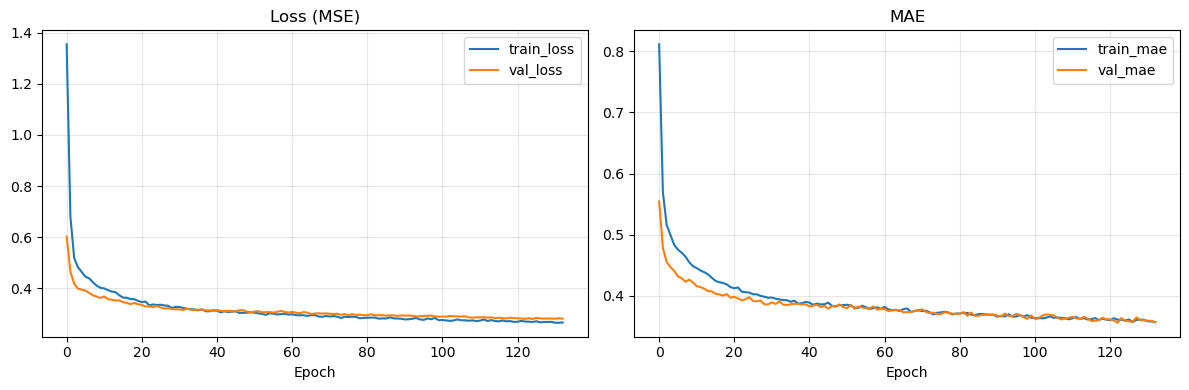

In [9]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['loss'], label='train_loss')
axes[0].plot(history_df['val_loss'], label='val_loss')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['mae'], label='train_mae')
axes[1].plot(history_df['val_mae'], label='val_mae')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Final Evaluation

This section reports final MLP metrics and residual diagnostics.

How to read printed metrics (`MLP -> MAE, RMSE, R2`): compare each metric directly against baseline. Large RMSE-vs-MAE gap indicates heavier penalty from occasional large errors. R2 indicates how much variance is captured.

How to read residual plots: residuals should be centered around zero and mostly pattern-free. Systematic structure suggests missing nonlinear effects, feature engineering opportunities, or model bias.

Go deeper: [MAE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html), [MSE/RMSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html), and [R2](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html).


MLP -> MAE: 0.3514, RMSE: 0.5166, R2: 0.8054


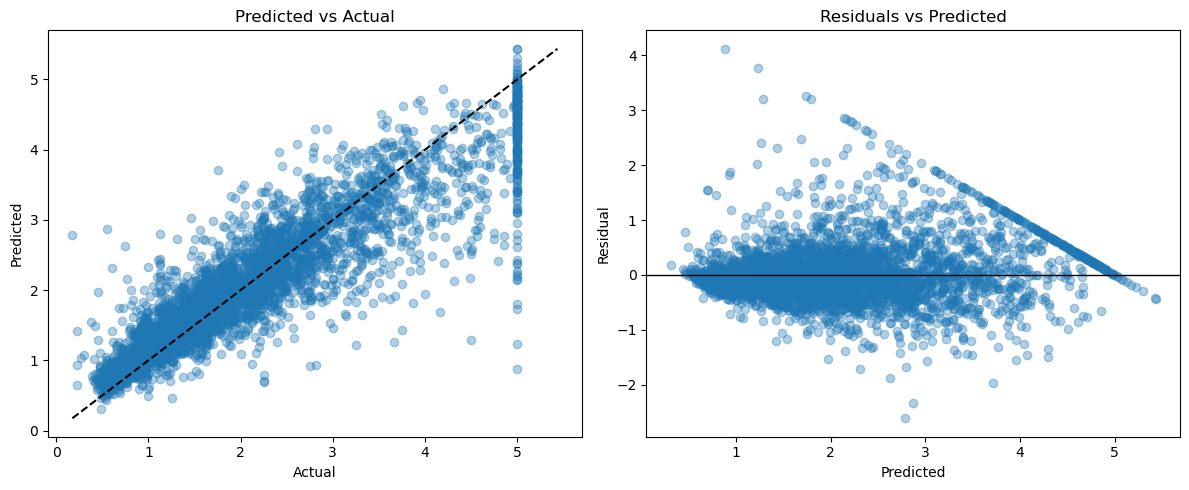

In [10]:
y_pred = model.predict(X_test_s, verbose=0).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MLP -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.35)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'k--')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.35)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()


## 11. Mini Exercises

Use this section as a structured experiment log. For each change, predict first, run second, and interpret outputs with evidence from both metrics and plots.


1. Remove dropout (`0.2 -> 0.0`) and explain how validation MAE changes.
2. Disable early stopping and describe overfitting signatures in training curves.
3. Reduce hidden-layer width (`64/32` to `32/16`) and discuss speed-versus-error tradeoffs.
4. Optional advanced extension: apply a log-transform to the target and discuss residual-shape changes.

For broader study, keep the [scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html) and [TensorFlow/Keras guides](https://www.tensorflow.org/guide/keras) open while experimenting.
